### Generic reactor parameters

In [23]:
from pathlib import Path
import sys

# Add notebook directory so reactor_parameters can be found
_cwd = Path.cwd().resolve()
_candidates = [_cwd, *_cwd.parents]
_nb_dir = next((p for p in _candidates if (p / "reactor_parameters.py").is_file()), None)
if _nb_dir is not None and str(_nb_dir) not in sys.path:
    sys.path.insert(0, str(_nb_dir))

import numpy as np
import matplotlib.pyplot as plt

from reactor_parameters import *


In [24]:
T_DHe3 = 70 # keV
V_DHe3 = 354 # m^3

# Direct square-wave tritium reinjection from storage.
t_reinjection_square_wave = {
    "rate_high": 1.05e23,
    "rate_low": 0.0,
    "period_s": 3600,
    "duty_cycle": 0.5,
    "phase_s": 0.0,
}

# Direct square-wave fresh fueling applied identically to D and He3.
dhe3_fuel_square_wave = {
    "rate_high": 1.05e21,
    "rate_low": 0.0,
    "period_s": 3600,
    "duty_cycle": 0.5,
    "phase_s": 0.0,
}

# DHe3 with T reinjection (up to 10% T)

In [25]:
species_params_dhe3 = {
    "D": {
        "f_0": 0.4995,
        "tau_p": tau_p_T,
        "tau_ifc": 4.0 * 3600.0,
        "tau_ofc": np.inf,
        "N_stor_min": 0.0,
        "Ndot_max": dhe3_fuel_square_wave["rate_high"],
        "injection_mode": "custom",
        "inject_from_storage": False,
        "square_wave": dict(dhe3_fuel_square_wave),
        "N_ofc_0": float(SPECIES_DEFAULTS["D"]["N_ofc_0"]),
        "N_ifc_0": float(SPECIES_DEFAULTS["D"]["N_ifc_0"]),
        "N_stor_0": float(SPECIES_DEFAULTS["D"]["N_stor_0"]),
        "enable_plasma_channel": True,
    },
    "T": {
        "f_0": 0.001,
        "tau_p": tau_p_T,
        "tau_ifc": 4.0 * 3600.0,
        "tau_ofc": 2.0 * 3600.0,
        "N_stor_min": 0.001 / species_mass["T"],
        "Ndot_max": t_reinjection_square_wave["rate_high"],
        "injection_mode": "custom",
        "inject_from_storage": True,
        "square_wave": dict(t_reinjection_square_wave),
        "N_ofc_0": float(SPECIES_DEFAULTS["T"]["N_ofc_0"]),
        "N_ifc_0": float(SPECIES_DEFAULTS["T"]["N_ifc_0"]),
        "N_stor_0": float(1.0 / species_mass["T"]),
        "enable_plasma_channel": True,
    },
    "He3": {
        "f_0": 0.4995,
        "tau_p": tau_p_T,
        "tau_ifc": 4.0 * 3600.0,
        "tau_ofc": np.inf,
        "N_stor_min": 0.0,
        "Ndot_max": dhe3_fuel_square_wave["rate_high"],
        "injection_mode": "custom",
        "inject_from_storage": False,
        "square_wave": dict(dhe3_fuel_square_wave),
        "N_ofc_0": float(SPECIES_DEFAULTS["He3"]["N_ofc_0"]),
        "N_ifc_0": float(SPECIES_DEFAULTS["He3"]["N_ifc_0"]),
        "N_stor_0": float(SPECIES_DEFAULTS["He3"]["N_stor_0"]),
        "enable_plasma_channel": True,
    },
    "He4": {
        "f_0": 0.0,
        "tau_p": tau_p_T,
        "tau_ifc": 4.0 * 3600.0,
        "tau_ofc": np.inf,
        "N_stor_min": 0.0,
        "Ndot_max": 0.0,
        "injection_mode": "off",
        "inject_from_storage": False,
        "N_ofc_0": float(SPECIES_DEFAULTS["He4"]["N_ofc_0"]),
        "N_ifc_0": float(SPECIES_DEFAULTS["He4"]["N_ifc_0"]),
        "N_stor_0": float(SPECIES_DEFAULTS["He4"]["N_stor_0"]),
        "enable_plasma_channel": True,
    },
}


In [26]:
def build_square_wave_request(square_wave_cfg):
    rate_high = float(square_wave_cfg["rate_high"])
    rate_low = float(square_wave_cfg.get("rate_low", 0.0))
    period_s = max(float(square_wave_cfg["period_s"]), 1.0e-12)
    duty_cycle = float(np.clip(square_wave_cfg.get("duty_cycle", 0.5), 0.0, 1.0))
    phase_s = float(square_wave_cfg.get("phase_s", 0.0))

    def request_fn(ctx):
        phase = ((float(ctx["t"]) + phase_s) % period_s) / period_s
        return rate_high if phase < duty_cycle else rate_low

    return request_fn


species_params = {}
for sp in SPECIES:
    sp_cfg = species_params_dhe3[sp]
    species_params[sp] = {
        "tau_p": float(sp_cfg["tau_p"]),
        "lambda_decay": float(sp_cfg.get("lambda_decay", SPECIES_DEFAULTS[sp]["lambda_decay"])),
        "tau_ifc": float(sp_cfg["tau_ifc"]),
        "tau_ofc": float(sp_cfg["tau_ofc"]),
        "N_stor_min": float(sp_cfg["N_stor_min"]),
        "Ndot_max": float(sp_cfg["Ndot_max"]),
        "inject_from_storage": bool(sp_cfg["inject_from_storage"]),
        "injection_mode": str(sp_cfg["injection_mode"]),
        "enable_plasma_channel": bool(sp_cfg["enable_plasma_channel"]),
    }
    if species_params[sp]["injection_mode"] == "custom":
        species_params[sp]["injection_custom_function"] = build_square_wave_request(sp_cfg["square_wave"])


initial_conditions = {
    sp: {
        "f_0": float(species_params_dhe3[sp]["f_0"]),
        "N_ofc_0": float(species_params_dhe3[sp]["N_ofc_0"]),
        "N_ifc_0": float(species_params_dhe3[sp]["N_ifc_0"]),
        "N_stor_0": float(species_params_dhe3[sp]["N_stor_0"]),
    }
    for sp in SPECIES
}
reactivities_dhe3 = compute_reactivities_from_functions(float(T_DHe3))

In [27]:
res_dhe3 = solve_multispecies_ode_system(
    V_plasma=float(V_DHe3),
    T_i=float(T_DHe3),
    n_tot=float(n_tot),
    species_params=species_params,
    initial_conditions=initial_conditions,
    TBR_DT=0,
    TBR_DDn=0,
    max_simulation_time=float(max_simulation_time),
    vector_length=int(vector_length),
    reactivities=reactivities_dhe3,
    target_conditions=[{"target_specie": "T", "metric": "fraction", "value": 0.10}],
)


In [28]:
if "t" not in res_dhe3:
    raise RuntimeError(
        "Solver failed without returning time arrays.\n"
        f"  success(target reached): {res_dhe3.get('sol_success', False)}\n"
        f"  error: {res_dhe3.get('error', 'unknown')}"
    )

t_ref = np.asarray(res_dhe3["t"], dtype=float)
n_D = np.maximum(np.asarray(res_dhe3.get("n_D", np.zeros_like(t_ref)), dtype=float), 0.0)
n_T = np.maximum(np.asarray(res_dhe3.get("n_T", np.zeros_like(t_ref)), dtype=float), 0.0)
n_He3 = np.maximum(np.asarray(res_dhe3.get("n_He3", np.zeros_like(t_ref)), dtype=float), 0.0)

(
    P_DDn,
    P_DDp,
    P_DT,
    P_DHe3,
    P_TT,
    P_He3He3,
    P_THe3_ch1,
    P_THe3_ch2,
    P_THe3_ch3,
    P_DT_eq,
) = compute_fusion_power_profiles_numba(
    n_D,
    n_T,
    n_He3,
    float(n_tot),
    float(V_DHe3),
    float(reactivities_dhe3["sigmav_DD_p"]),
    float(reactivities_dhe3["sigmav_DD_n"]),
    float(reactivities_dhe3["sigmav_DT"]),
    float(reactivities_dhe3["sigmav_DHe3"]),
    float(reactivities_dhe3["sigmav_TT"]),
    float(reactivities_dhe3["sigmav_He3He3"]),
    float(reactivities_dhe3["sigmav_THe3_ch1"]),
    float(reactivities_dhe3["sigmav_THe3_ch2"]),
    float(reactivities_dhe3["sigmav_THe3_ch3"]),
)

P_fusion_total = P_DDn + P_DDp + P_DT + P_DHe3 + P_TT + P_He3He3 + P_THe3_ch1 + P_THe3_ch2 + P_THe3_ch3
P_DDn = np.asarray(P_DDn, dtype=float)
P_DDp = np.asarray(P_DDp, dtype=float)
P_DT = np.asarray(P_DT, dtype=float)
P_DHe3 = np.asarray(P_DHe3, dtype=float)
P_TT = np.asarray(P_TT, dtype=float)
P_He3He3 = np.asarray(P_He3He3, dtype=float)
P_THe3_ch1 = np.asarray(P_THe3_ch1, dtype=float)
P_THe3_ch2 = np.asarray(P_THe3_ch2, dtype=float)
P_THe3_ch3 = np.asarray(P_THe3_ch3, dtype=float)
P_DT_eq = np.asarray(P_DT_eq, dtype=float)
P_fusion_total = np.asarray(P_fusion_total, dtype=float)


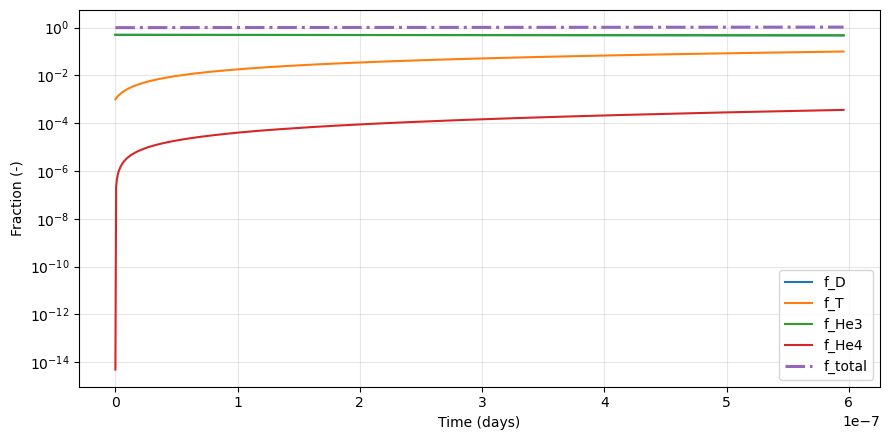

In [29]:
# Plasma fractions
fig, ax = plt.subplots(1, 1, figsize=(9, 4.5))
t_days = np.asarray(res_dhe3["t"], dtype=float) / 86400.0
for sp in SPECIES:
    key = f"n_{sp}"
    if key in res_dhe3:
        ax.plot(t_days, np.asarray(res_dhe3[key], dtype=float) / n_tot, label=f"f_{sp}")
total = np.zeros_like(t_days, dtype=float)
for sp in SPECIES:
    key = f"n_{sp}"
    if key in res_dhe3:
        total = total + np.asarray(res_dhe3[key], dtype=float)
ax.plot(t_days, total / n_tot, lw=2.2, ls='-.', label="f_total")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Fraction (-)")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


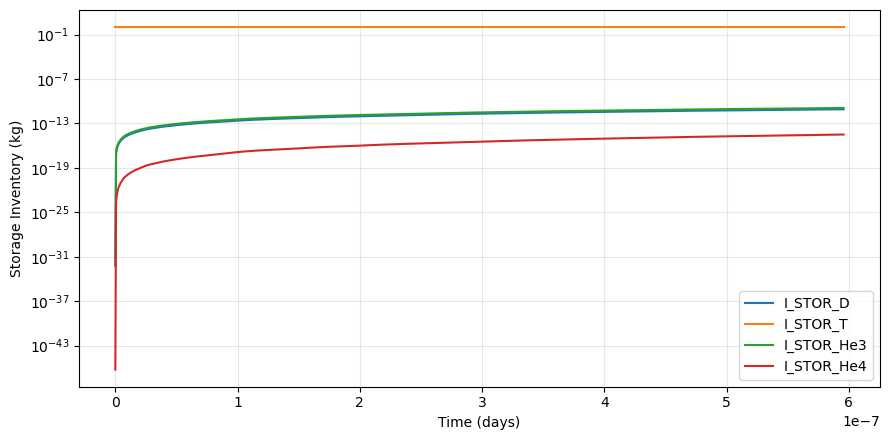

In [30]:
# Storage inventories
fig, ax = plt.subplots(1, 1, figsize=(9, 4.5))
t_days = np.asarray(res_dhe3["t"], dtype=float) / 86400.0
for sp in SPECIES:
    key = f"N_stor_{sp}"
    if key in res_dhe3:
        ax.plot(t_days, np.asarray(res_dhe3[key], dtype=float) * species_mass[sp], label=f"I_STOR_{sp}")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Storage Inventory (kg)")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


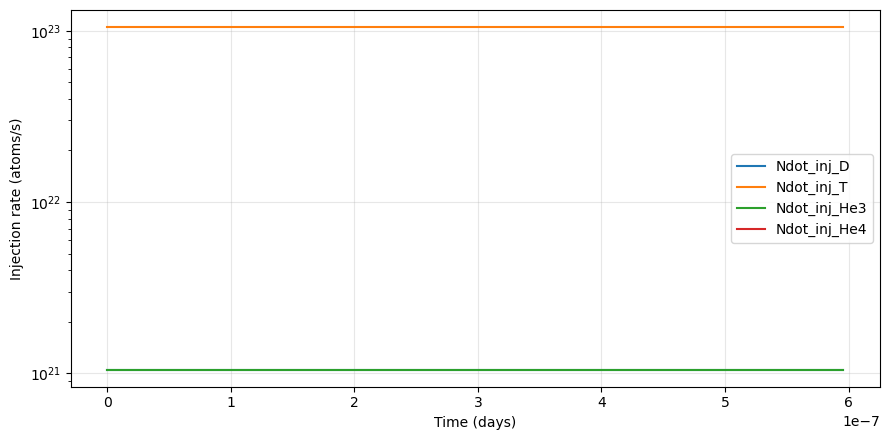

In [31]:
# Injection rates
fig, ax = plt.subplots(1, 1, figsize=(9, 4.5))
t_days = np.asarray(res_dhe3["t"], dtype=float) / 86400.0
for sp in SPECIES:
    key = f"Ndot_inj_{sp}"
    if key in res_dhe3:
        ax.plot(t_days, np.asarray(res_dhe3[key], dtype=float), label=f"Ndot_inj_{sp}")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Injection rate (atoms/s)")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


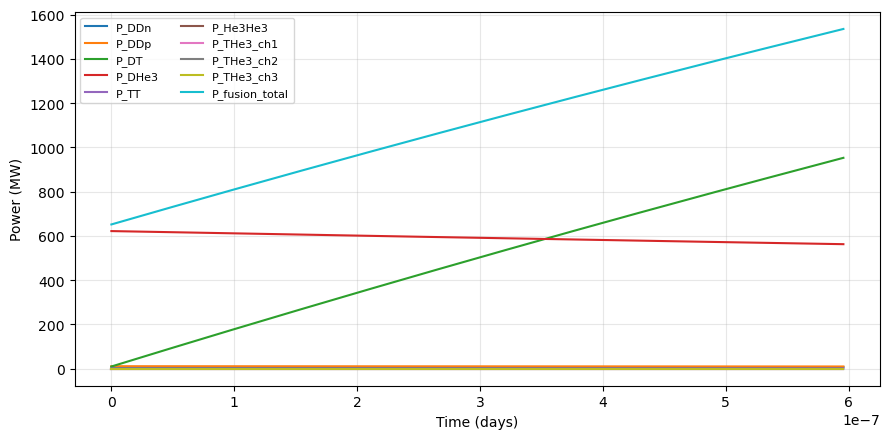

In [32]:
# Fusion powers
fig, ax = plt.subplots(1, 1, figsize=(9, 4.5))
t_days = np.asarray(res_dhe3["t"], dtype=float) / 86400.0
reaction_series = [
    ("P_DDn", P_DDn),
    ("P_DDp", P_DDp),
    ("P_DT", P_DT),
    ("P_DHe3", P_DHe3),
    ("P_TT", P_TT),
    ("P_He3He3", P_He3He3),
    ("P_THe3_ch1", P_THe3_ch1),
    ("P_THe3_ch2", P_THe3_ch2),
    ("P_THe3_ch3", P_THe3_ch3),
    ("P_fusion_total", P_fusion_total),
]
for label, series in reaction_series:
    ax.plot(t_days, np.asarray(series, dtype=float) * 1.0e-6, label=label)
ax.set_xlabel("Time (days)")
ax.set_ylabel("Power (MW)")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()
